In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Cài đặt các thư viện bổ trợ
!pip install quantus shap lime xgboost statsmodels

import pandas as pd
import numpy as np
import shap
import lime
import lime.lime_tabular
import xgboost as xgb
import quantus
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Môi trường đã sẵn sàng.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.8/281.8 kB 22.3 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=911303a72fee34cb964788c3c8c981720fe2ebc9fb3191970a1a2ec0c1e722d3
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Môi trường đã sẵn sàng.


# Đọc dữ liệu

In [ ]:
import pandas as pd
import os
from google.colab import drive

# 1. Kết nối Google Drive
drive.mount('/content/drive')

# 2. Đường dẫn thư mục (Đã cập nhật theo yêu cầu của bạn)
folder_path = '/content/drive/MyDrive/Master/Colab Data/NHANES/'

def load_nhanes_file(file_name, columns):
    full_path = os.path.join(folder_path, file_name)
    if os.path.exists(full_path):
        # Đọc file .xpt
        df = pd.read_sas(full_path)
        # Đảm bảo tên cột luôn viết hoa để đồng nhất
        df.columns = [c.upper() for c in df.columns]
        # Lấy cột SEQN và các cột đặc trưng được yêu cầu
        return df[['SEQN'] + [c.upper() for c in columns]]
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy file {file_name} tại {folder_path}")
        return None

# 3. Đọc dữ liệu từ 10 file (Tổng cộng 15 biến + SEQN)
# Nhóm 1: Nhân khẩu học (3 biến)
df_demo = load_nhanes_file('DEMO_L.xpt', ['RIDAGEYR', 'RIAGENDR', 'RIDRETH3'])

# Nhóm 2: Hình thể (3 biến)
df_bmi  = load_nhanes_file('BMX_L.xpt', ['BMXBMI', 'BMXWAIST', 'BMXWT'])

# Nhóm 3: Huyết áp (2 biến)
df_bp   = load_nhanes_file('BPXO_L.xpt', ['BPXOSY1', 'BPXODI1'])

# Nhóm 4: Sinh hóa - Lab (4 biến)
df_glu  = load_nhanes_file('GLU_L.xpt', ['LBDGLUSI'])
df_chol = load_nhanes_file('TCHOL_L.xpt', ['LBDTCSI'])
df_hdl  = load_nhanes_file('HDL_L.xpt', ['LBDHDDSI'])
df_tri  = load_nhanes_file('TRIGLY_L.xpt', ['LBDTRSI'])

# Nhóm 5: Lối sống (3 biến mới bổ sung)
df_paq  = load_nhanes_file('PAQ_L.xpt', ['PAD680'])
df_smq  = load_nhanes_file('SMQ_L.xpt', ['SMQ020'])
df_slq  = load_nhanes_file('SLQ_L.xpt', ['SLD012'])

# 4. Danh sách các DataFrame để in kiểm tra (Cập nhật đủ 10 nhóm)
dataframes = {
    "1. Nhân khẩu học (Demographics)": df_demo,
    "2. Chỉ số BMI (Body Measures)": df_bmi,
    "3. Huyết áp (Blood Pressure)": df_bp,
    "4. Đường huyết (Glucose)": df_glu,
    "5. Cholesterol toàn phần": df_chol,
    "6. HDL Cholesterol": df_hdl,
    "7. Triglycerides": df_tri,
    "8. Vận động (Physical Activity)": df_paq,
    "9. Hút thuốc (Smoking)": df_smq,
    "10. Giấc ngủ (Sleep)": df_slq
}

# 5. Vòng lặp in ra thông tin kiểm tra từng bảng
print(f"{'NHÓM DỮ LIỆU':<35} | {'SỐ DÒNG':<10} | {'SỐ CỘT':<8}")
print("-" * 60)

for title, df_obj in dataframes.items():
    if df_obj is not None:
        print(f"{title:<35} | {df_obj.shape[0]:<10} | {df_obj.shape[1]:<8}")
        # Hiển thị 5 dòng đầu dạng bảng đẹp trong Colab
        # display(df_obj.head()) # Bỏ comment nếu muốn xem bảng chi tiết
    else:
        print(f"{title:<35} | LỖI LOAD FILE")

print("\n--- Kiểm tra 5 dòng đầu của bảng cuối cùng (Giấc ngủ) làm mẫu ---")
if df_slq is not None:
    print(df_slq.head())

Mounted at /content/drive
NHÓM DỮ LIỆU                        | SỐ DÒNG    | SỐ CỘT  
------------------------------------------------------------
1. Nhân khẩu học (Demographics)     | 11933      | 4       
2. Chỉ số BMI (Body Measures)       | 8860       | 4       
3. Huyết áp (Blood Pressure)        | 7801       | 3       
4. Đường huyết (Glucose)            | 3996       | 2       
5. Cholesterol toàn phần            | 8068       | 2       
6. HDL Cholesterol                  | 8068       | 2       
7. Triglycerides                    | 3996       | 2       
8. Vận động (Physical Activity)     | 8153       | 2       
9. Hút thuốc (Smoking)              | 9015       | 2       
10. Giấc ngủ (Sleep)                | 8501       | 2       

--- Kiểm tra 5 dòng đầu của bảng cuối cùng (Giấc ngủ) làm mẫu ---
       SEQN  SLD012
0  130378.0     9.5
1  130379.0     9.0
2  130380.0     8.0
3  130384.0     7.5
4  130385.0     8.0


# Gộp dữ liệu

In [ ]:
# 1. Thực hiện gộp tất cả 10 bảng (Sử dụng Inner Join theo SEQN)
df_merged = df_demo.merge(df_bmi, on='SEQN') \
                   .merge(df_bp, on='SEQN') \
                   .merge(df_glu, on='SEQN') \
                   .merge(df_chol, on='SEQN') \
                   .merge(df_hdl, on='SEQN') \
                   .merge(df_tri, on='SEQN') \
                   .merge(df_paq, on='SEQN') \
                   .merge(df_smq, on='SEQN') \
                   .merge(df_slq, on='SEQN')

# 2. Tính toán số liệu trước khi xóa NaN
total_rows_after_merge = len(df_merged)
rows_with_nan = df_merged.isna().any(axis=1).sum()

# 3. Thực hiện loại bỏ các dòng có NaN
df_clean = df_merged.dropna()
final_rows = len(df_clean)

# 4. In báo cáo chi tiết
print("="*60)
print("BÁO CÁO PHÂN TÍCH DỮ LIỆU SAU GỘP")
print("="*60)
print(f"🔹 Tổng số dòng sau khi gộp (Merge):       {total_rows_after_merge}")
print(f"🔸 Số dòng có ít nhất một giá trị NaN:     {rows_with_nan}")
print(f"✅ Số dòng sạch cuối cùng (Sau drop NaN):  {final_rows}")
print(f"📉 Tỷ lệ dữ liệu bị loại bỏ:               {round((rows_with_nan/total_rows_after_merge)*100, 2)}%")
print("-" * 60)

# 5. Kiểm tra xem cột nào bị thiếu nhiều nhất (Để bạn nắm tình hình)
print("THỐNG KÊ GIÁ TRỊ THIẾU TRÊN TỪNG CỘT:")
print(df_merged.isna().sum()[df_merged.isna().sum() > 0])
print("-" * 60)

# 6. Hiển thị dữ liệu sạch
print("DANH SÁCH 15 ĐẶC TRƯNG SẴN SÀNG CHO THỰC NGHIỆM:")
display(df_clean.head())

BÁO CÁO PHÂN TÍCH DỮ LIỆU SAU GỘP
🔹 Tổng số dòng sau khi gộp (Merge):       3562
🔸 Số dòng có ít nhất một giá trị NaN:     600
✅ Số dòng sạch cuối cùng (Sau drop NaN):  2962
📉 Tỷ lệ dữ liệu bị loại bỏ:               16.84%
------------------------------------------------------------
THỐNG KÊ GIÁ TRỊ THIẾU TRÊN TỪNG CỘT:
BMXBMI       50
BMXWAIST    175
BMXWT        43
BPXOSY1     131
BPXODI1     131
LBDGLUSI    233
LBDTCSI     351
LBDHDDSI    351
LBDTRSI     373
PAD680        4
SMQ020        1
SLD012       31
dtype: int64
------------------------------------------------------------
DANH SÁCH 15 ĐẶC TRƯNG SẴN SÀNG CHO THỰC NGHIỆM:


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,BMXBMI,BMXWAIST,BMXWT,BPXOSY1,BPXODI1,LBDGLUSI,LBDTCSI,LBDHDDSI,LBDTRSI,PAD680,SMQ020,SLD012
0,130378.0,43.0,1.0,6.0,27.0,98.3,86.9,135.0,98.0,6.27,6.83,1.16,1.727,360.0,1.0,9.5
1,130379.0,66.0,1.0,3.0,33.5,114.7,101.8,121.0,84.0,5.50,5.53,1.55,0.971,480.0,1.0,9.0
2,130380.0,44.0,2.0,2.0,29.7,93.5,69.4,111.0,79.0,8.66,4.84,1.27,4.234,240.0,2.0,8.0
3,130386.0,34.0,1.0,1.0,30.2,106.1,90.6,110.0,72.0,5.55,4.73,1.19,1.603,180.0,1.0,7.5
4,130394.0,51.0,1.0,3.0,24.4,92.1,76.7,99.0,69.0,4.88,4.73,1.24,0.644,420.0,2.0,8.0


# VIF: before & after Loại thuộc tính

🚀 QUY TRÌNH TINH CHẾ THEO CHUẨN IEEE 2894-2024

--- Đang thực hiện loại bỏ đa cộng tuyến từng bước ---
  ❌ Đã loại: BMXWAIST     | VIF cũ: 331.05
  ❌ Đã loại: BMXBMI       | VIF cũ: 158.34
  ❌ Đã loại: BPXOSY1      | VIF cũ: 93.83
  ❌ Đã loại: BPXODI1      | VIF cũ: 48.48
  ❌ Đã loại: LBDTCSI      | VIF cũ: 29.19
  ❌ Đã loại: SLD012       | VIF cũ: 24.83
  ❌ Đã loại: LBDHDDSI     | VIF cũ: 19.58
  ❌ Đã loại: BMXWT        | VIF cũ: 14.24


/tmp/ipykernel_3987/553794345.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="Feature", data=vif_before, palette="viridis", ax=ax1)
/tmp/ipykernel_3987/553794345.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="Feature", data=vif_after, palette="magma", ax=ax2)


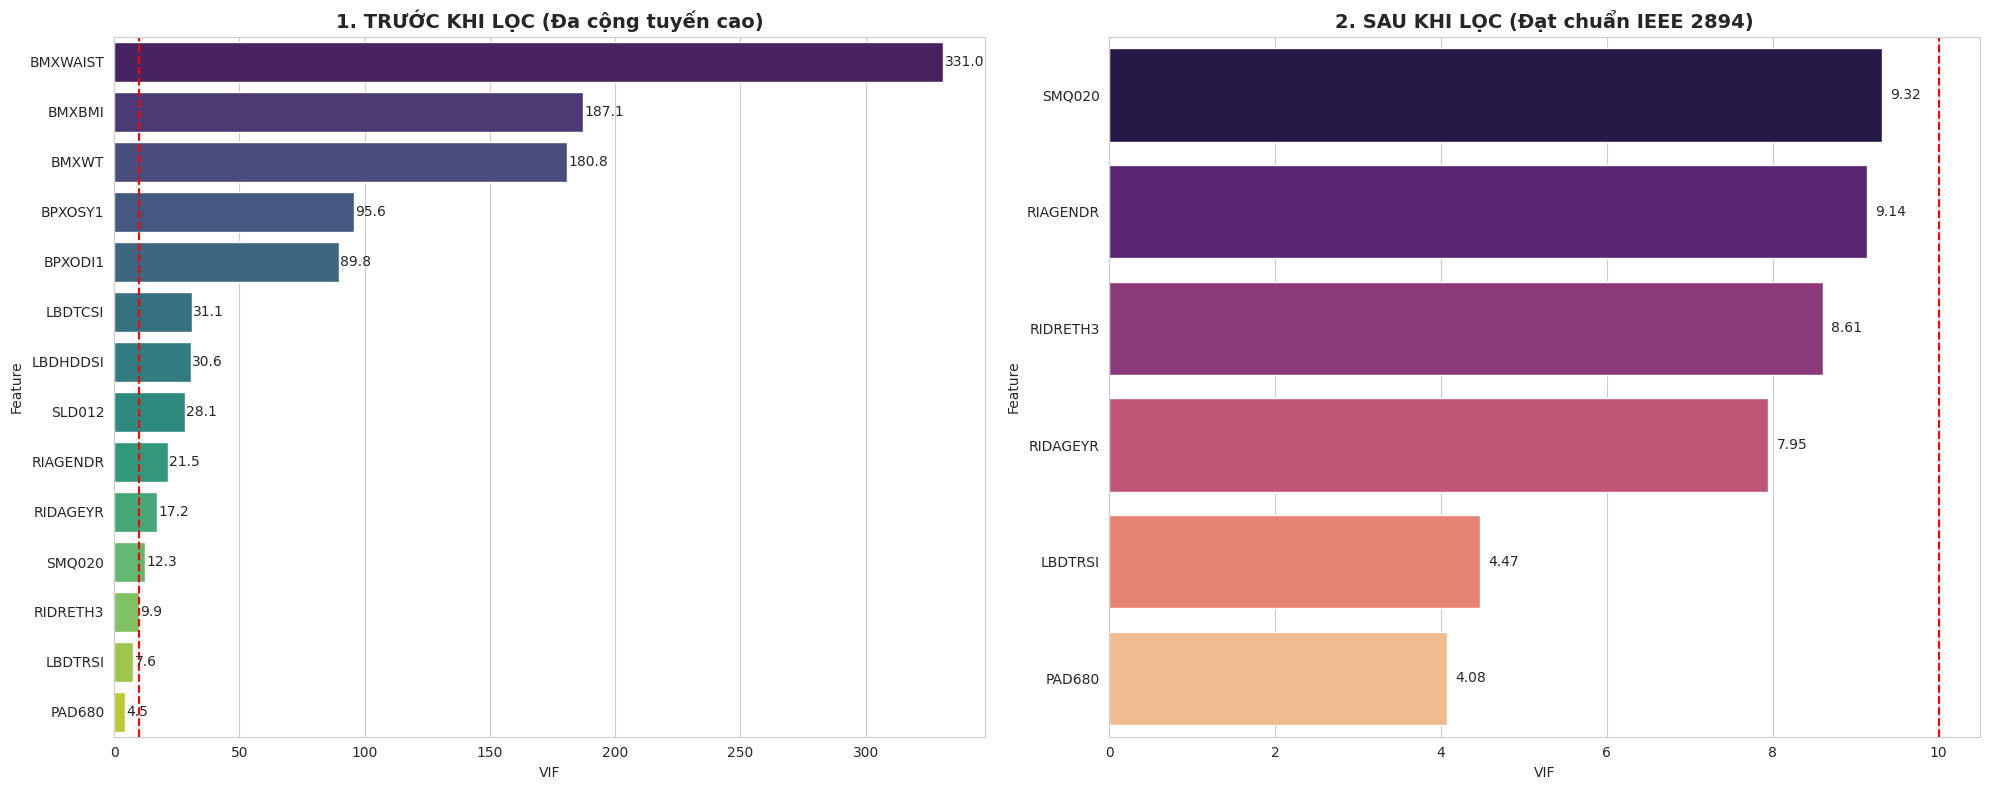


✅ HOÀN TẤT: Đã loại bỏ 8 biến: ['BMXWAIST', 'BMXBMI', 'BPXOSY1', 'BPXODI1', 'LBDTCSI', 'SLD012', 'LBDHDDSI', 'BMXWT']
📊 Số lượng biến còn lại: 6 | Số mẫu: 2674


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Khởi tạo dữ liệu
df_working = df_clean.copy()
print("🚀 QUY TRÌNH TINH CHẾ THEO CHUẨN IEEE 2894-2024\n")

# --- BƯỚC 1: XỬ LÝ MÃ ĐẶC BIỆT ---
target_cols = ['SMQ020', 'RIAGENDR', 'RIDRETH3']
for col in target_cols:
    mode_val = df_working[col].mode()[0]
    df_working[col] = df_working[col].replace([7, 9, 77, 99], mode_val)

# --- BƯỚC 2: LOẠI BỎ OUTLIERS ---
continuous_cols = ['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BPXOSY1', 'BPXODI1',
                   'LBDGLUSI', 'LBDTCSI', 'LBDHDDSI', 'LBDTRSI', 'PAD680', 'SLD012']
z_scores = np.abs(stats.zscore(df_working[continuous_cols]))
df_working = df_working[(z_scores < 3).all(axis=1)]

# --- BƯỚC 3: HÀM TÍNH VIF VÀ LOẠI BỎ TỪNG BƯỚC ---
def get_vif_df(df):
    X_vif = df.drop(columns=['SEQN', 'LBDGLUSI'])
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

# Tính VIF ban đầu (Trước khi lọc)
vif_before = get_vif_df(df_working)

# Quy trình loại bỏ lặp (Stepwise) theo IEEE
df_final = df_working.copy()
dropped_features = []
threshold = 10.0

print("--- Đang thực hiện loại bỏ đa cộng tuyến từng bước ---")
while True:
    vif_current = get_vif_df(df_final)
    max_vif = vif_current['VIF'].max()
    if max_vif > threshold:
        # Lấy tên biến có VIF cao nhất
        feature_to_drop = vif_current.iloc[0]['Feature']
        dropped_features.append(feature_to_drop)
        df_final = df_final.drop(columns=[feature_to_drop])
        print(f"  ❌ Đã loại: {feature_to_drop:12} | VIF cũ: {max_vif:.2f}")
    else:
        break

# VIF sau khi lọc
vif_after = get_vif_df(df_final)

# --- BƯỚC 4: VẼ BIỂU ĐỒ SO SÁNH TRƯỚC VÀ SAU ---
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Chart 1: Trước khi loại bỏ
sns.barplot(x="VIF", y="Feature", data=vif_before, palette="viridis", ax=ax1)
ax1.axvline(x=10, color='red', linestyle='--')
ax1.set_title("1. TRƯỚC KHI LỌC (Đa cộng tuyến cao)", fontsize=14, fontweight='bold')
for p in ax1.patches:
    ax1.text(p.get_width() + 0.5, p.get_y() + p.get_height()/2, f'{p.get_width():.1f}', va='center')

# Chart 2: Sau khi lọc (Recursive)
sns.barplot(x="VIF", y="Feature", data=vif_after, palette="magma", ax=ax2)
ax2.axvline(x=10, color='red', linestyle='--')
ax2.set_title("2. SAU KHI LỌC (Đạt chuẩn IEEE 2894)", fontsize=14, fontweight='bold')
for p in ax2.patches:
    ax2.text(p.get_width() + 0.1, p.get_y() + p.get_height()/2, f'{p.get_width():.2f}', va='center')

plt.tight_layout()
plt.show()

print(f"\n✅ HOÀN TẤT: Đã loại bỏ {len(dropped_features)} biến: {dropped_features}")
print(f"📊 Số lượng biến còn lại: {len(vif_after)} | Số mẫu: {len(df_final)}")

# In Dữ Liệu

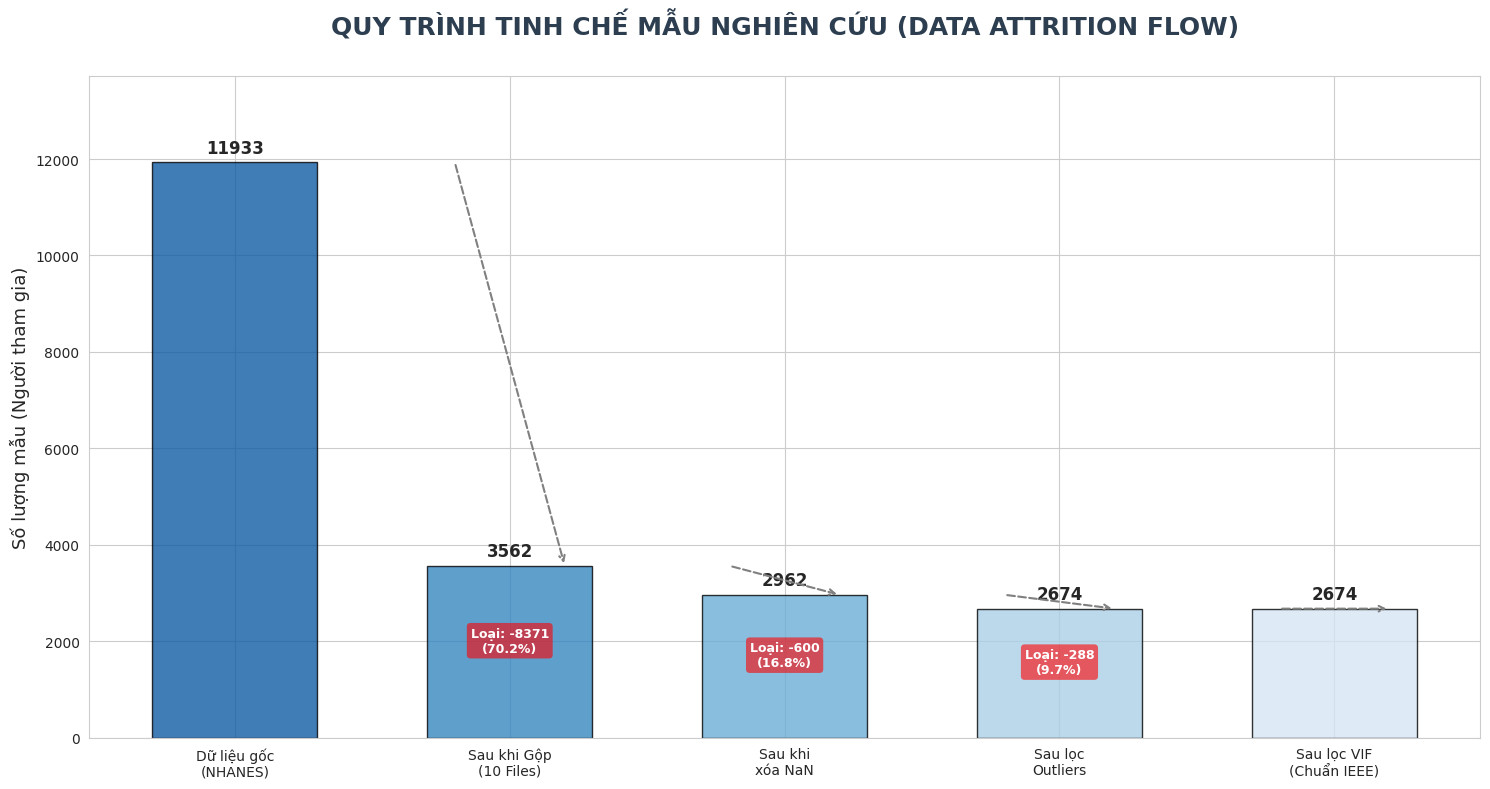

📊 BÁO CÁO HAO HỤT DỮ LIỆU:
   - Tổng mẫu ban đầu  : 11933
   - Mẫu sạch cuối cùng: 2674
   - Tỷ lệ hao hụt tổng: 77.59%
   - Tỷ lệ giữ lại     : 22.41%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# CẬP NHẬT BIỂU ĐỒ HAO HỤT DỮ LIỆU (DATA ATTRITION) - CHUẨN IEEE 2894
# =============================================================================

try:
    # 1. Thu thập số liệu động (Đảm bảo các biến này đã tồn tại trong Memory)
    count_original = len(df_demo)    # Gốc
    count_merged   = len(df_merged)  # Sau gộp
    count_no_nan   = len(df_clean)   # Sau xóa NaN
    count_no_out   = len(df_working) # Sau lọc Outliers
    count_final    = len(df_final)   # SAU LỌC VIF (Bước mới cập nhật)

    # Danh sách các bước và giá trị tương ứng
    steps = [
        'Dữ liệu gốc\n(NHANES)',
        'Sau khi Gộp\n(10 Files)',
        'Sau khi\nxóa NaN',
        'Sau lọc\nOutliers',
        'Sau lọc VIF\n(Chuẩn IEEE)'
    ]
    counts = [count_original, count_merged, count_no_nan, count_no_out, count_final]

    # 2. Tính toán số lượng và % bị mất (dropped)
    dropped = [0]
    dropped_pct = [0]
    for i in range(1, len(counts)):
        diff = counts[i-1] - counts[i]
        dropped.append(diff)
        dropped_pct.append((diff / counts[i-1]) * 100)

    # 3. Khởi tạo biểu đồ
    plt.figure(figsize=(15, 8))
    sns.set_style("whitegrid")

    # Sử dụng bảng màu chuyên nghiệp (Gradient từ đậm đến nhạt)
    colors = sns.color_palette("Blues_r", len(steps))
    bars = plt.bar(steps, counts, color=colors, alpha=0.8, edgecolor='black', width=0.6)

    # 4. Thêm thông số chi tiết lên biểu đồ
    for i, bar in enumerate(bars):
        yval = bar.get_height()

        # Số lượng còn lại trên đầu cột
        plt.text(bar.get_x() + bar.get_width()/2, yval + (count_original * 0.01),
                 f'{int(yval)}', ha='center', va='bottom', fontweight='bold', fontsize=12)

        # Hiển thị số lượng và % bị loại bỏ (vẽ giữa khoảng trống của 2 cột)
        if dropped[i] > 0:
            drop_text = f'Loại: -{int(dropped[i])}\n({dropped_pct[i]:.1f}%)'
            plt.text(bar.get_x() + bar.get_width()/2, yval / 2,
                     drop_text, ha='center', color='white',
                     fontweight='bold', fontsize=9,
                     bbox=dict(facecolor='red', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.3'))

    # 5. Tinh chỉnh thẩm mỹ (Phóng to tiêu đề và nhãn)
    plt.title('QUY TRÌNH TINH CHẾ MẪU NGHIÊN CỨU (DATA ATTRITION FLOW)',
              fontsize=18, pad=30, fontweight='bold', color='#2c3e50')
    plt.ylabel('Số lượng mẫu (Người tham gia)', fontsize=13)
    plt.ylim(0, count_original * 1.15)

    # Vẽ đường mũi tên kết nối
    for i in range(len(steps)-1):
        plt.annotate('', xy=(i+1.2, counts[i+1]), xytext=(i+0.8, counts[i]),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, ls='--'))

    plt.tight_layout()
    plt.show()

    # 6. In bảng tổng kết cuối cùng cho báo cáo
    print(f"📊 BÁO CÁO HAO HỤT DỮ LIỆU:")
    print(f"   - Tổng mẫu ban đầu  : {count_original}")
    print(f"   - Mẫu sạch cuối cùng: {count_final}")
    print(f"   - Tỷ lệ hao hụt tổng: {round((1 - count_final/count_original)*100, 2)}%")
    print(f"   - Tỷ lệ giữ lại     : {round((count_final/count_original)*100, 2)}%")

except NameError as e:
    print(f"❌ Lỗi: Bạn chưa chạy các bước xử lý dữ liệu trước đó.\nChi tiết: {e}")

# SHAP: Feature importance: before & after VIF

⏳ Đang xử lý Mô hình 1 (Trước khi lọc VIF - 14 biến)...
⏳ Đang xử lý Mô hình 2 (Sau khi lọc VIF - 6 biến chuẩn IEEE)...

📊 BÁO CÁO ĐỐI CHỨNG HIỆU NĂNG MÔ HÌNH
--------------------------------------------------
Chỉ số               | Trước lọc VIF   | Sau lọc VIF    
Số lượng đặc trưng   | 14              | 6              
MAE (mmol/L)         | 0.6128          | 0.6293         
R2 Score             | 0.2005          | 0.1679         



/tmp/ipykernel_3987/3414337418.py:70: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_before, X_test_before, show=False, plot_size=None)
/tmp/ipykernel_3987/3414337418.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_after, X_test_after, show=False, plot_size=None)


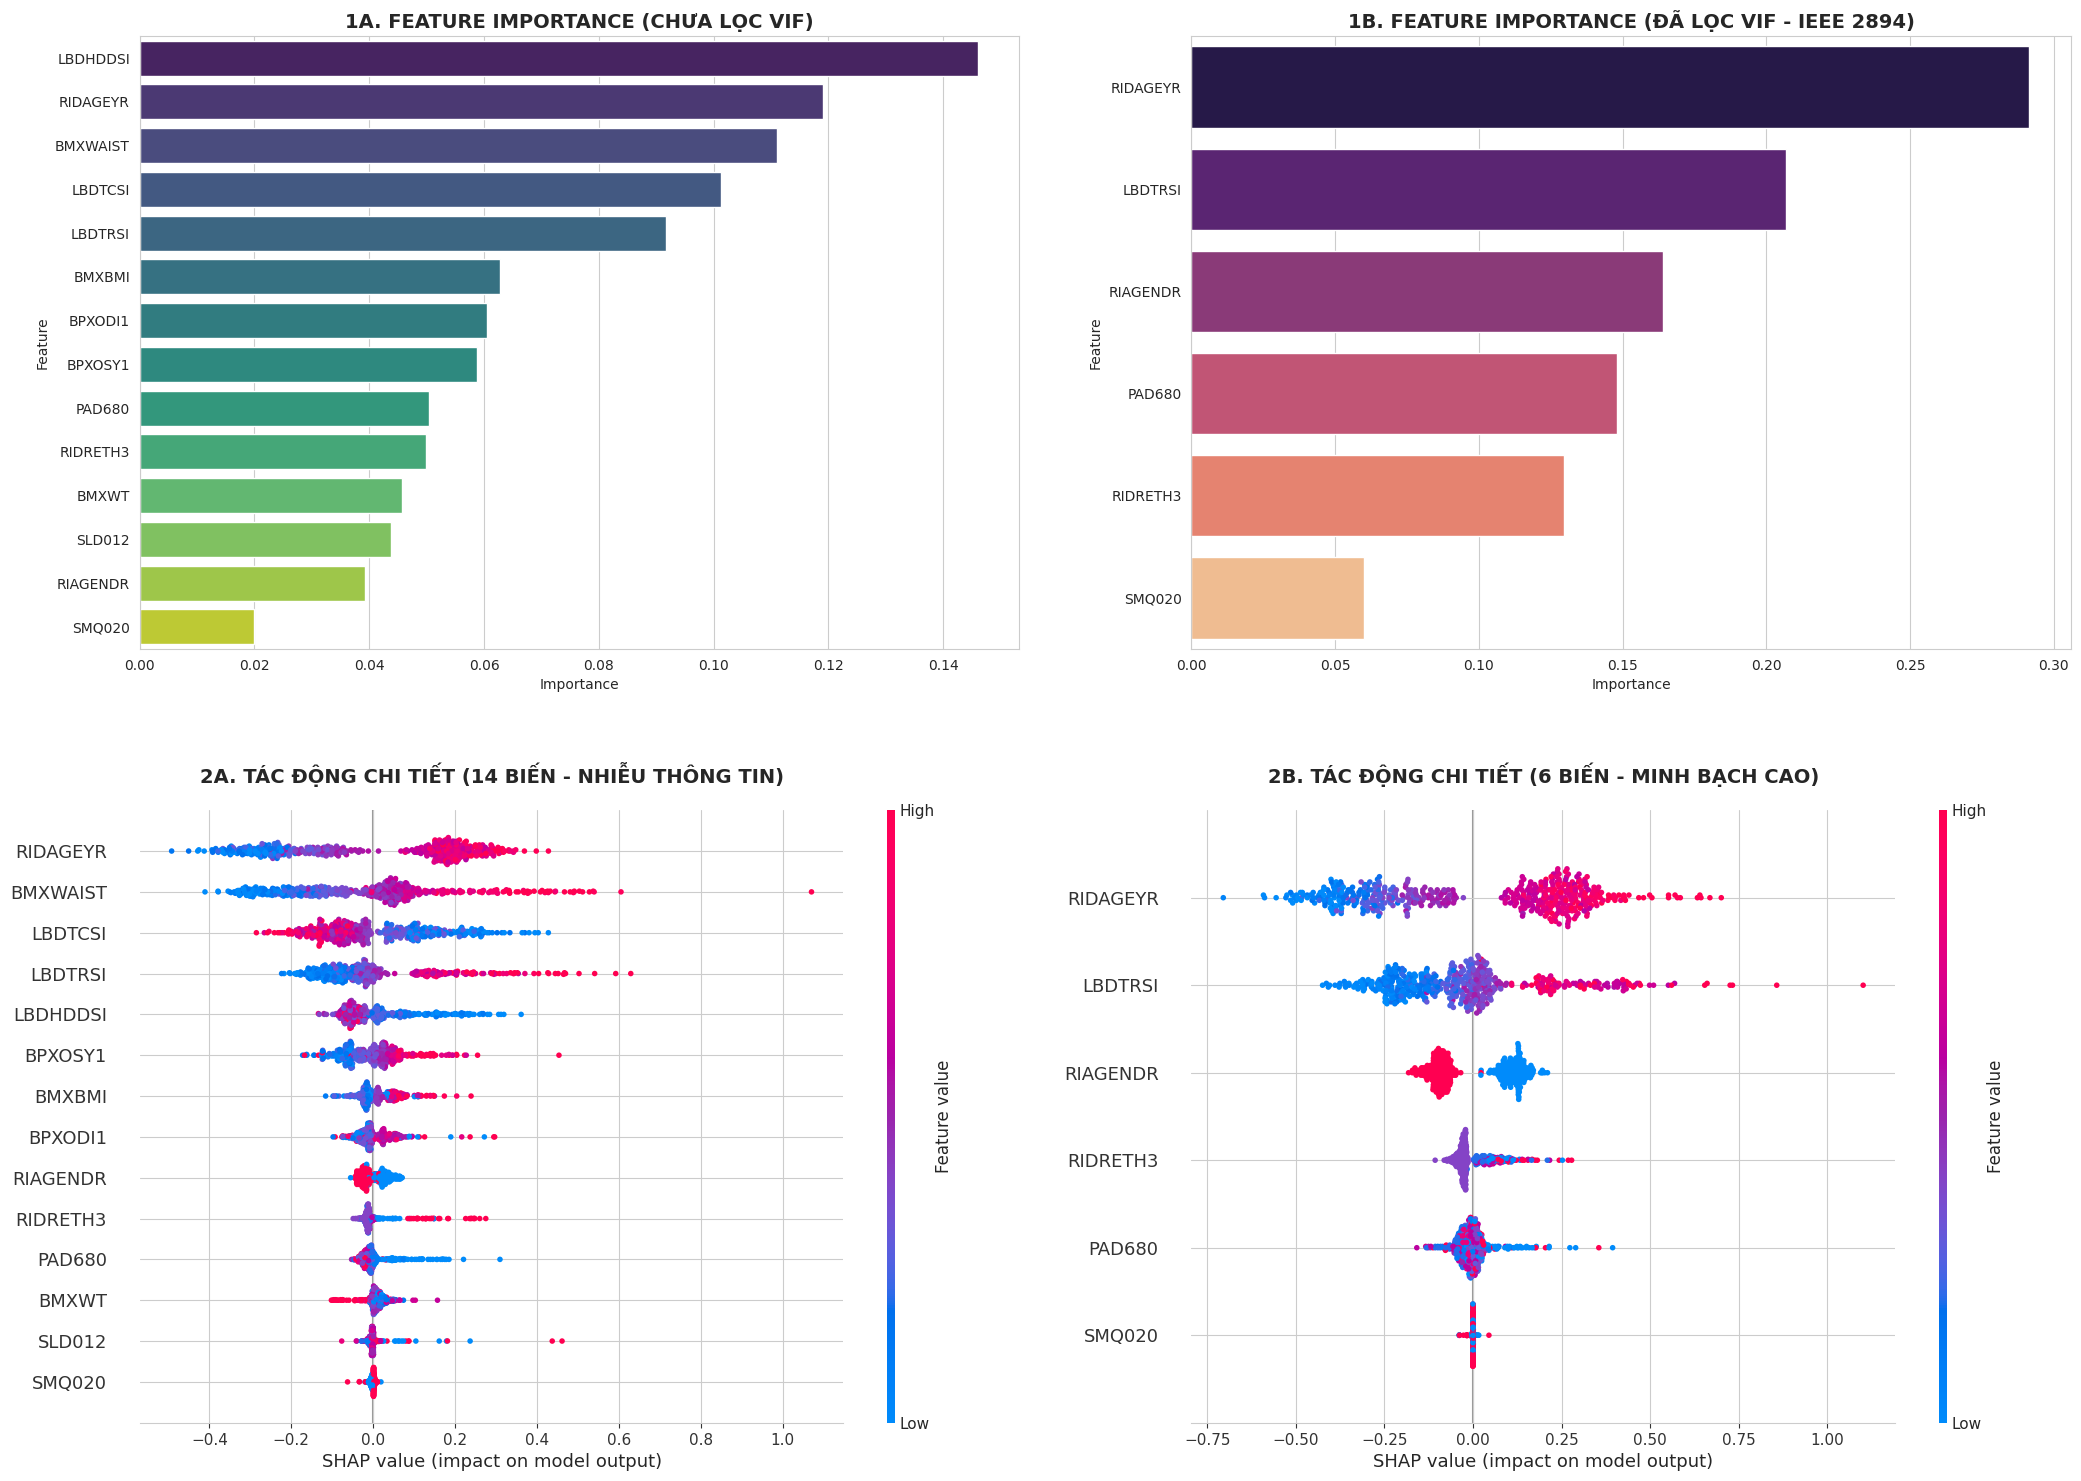

✅ QUY TRÌNH HOÀN TẤT. Dữ liệu đã được đối chứng định lượng.


In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Hàm xử lý tích hợp: Train -> Evaluate -> Importance -> SHAP
def get_model_and_shap(df):
    # Chuẩn bị dữ liệu
    X = df.drop(columns=['SEQN', 'LBDGLUSI'])
    y = df['LBDGLUSI']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Huấn luyện XGBoost (Cấu hình chuẩn)
    model = xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.01, random_state=42)
    model.fit(X_train, y_train)

    # Đánh giá hiệu năng
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Tính Feature Importance (Gain)
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Tính toán SHAP
    explainer = shap.Explainer(model)
    shap_values = explainer(X_test)

    return importance_df, shap_values, X_test, mae, r2

# --- THỰC HIỆN TÍNH TOÁN CHO CẢ 2 GIAI ĐOẠN ---
print("⏳ Đang xử lý Mô hình 1 (Trước khi lọc VIF - 14 biến)...")
imp_before, shap_before, X_test_before, mae_before, r2_before = get_model_and_shap(df_working)

print("⏳ Đang xử lý Mô hình 2 (Sau khi lọc VIF - 6 biến chuẩn IEEE)...")
imp_after, shap_after, X_test_after, mae_after, r2_after = get_model_and_shap(df_final)

# --- IN KẾT QUẢ ĐỐI CHỨNG HIỆU NĂNG ---
print("\n" + "="*50)
print("📊 BÁO CÁO ĐỐI CHỨNG HIỆU NĂNG MÔ HÌNH")
print("-" * 50)
print(f"{'Chỉ số':<20} | {'Trước lọc VIF':<15} | {'Sau lọc VIF':<15}")
print(f"{'Số lượng đặc trưng':<20} | {'14':<15} | {'6':<15}")
print(f"{'MAE (mmol/L)':<20} | {mae_before:<15.4f} | {mae_after:<15.4f}")
print(f"{'R2 Score':<20} | {r2_before:<15.4f} | {r2_after:<15.4f}")
print("="*50 + "\n")

# --- VẼ BIỂU ĐỒ TỔNG HỢP SO SÁNH (Giữ nguyên logic cũ) ---
fig = plt.figure(figsize=(22, 16))
sns.set_style("whitegrid")

# HÀNG 1: FEATURE IMPORTANCE
ax1 = fig.add_subplot(221)
sns.barplot(x="Importance", y="Feature", data=imp_before, palette="viridis", ax=ax1, hue="Feature", legend=False)
ax1.set_title("1A. FEATURE IMPORTANCE (CHƯA LỌC VIF)", fontsize=14, fontweight='bold')

ax2 = fig.add_subplot(222)
sns.barplot(x="Importance", y="Feature", data=imp_after, palette="magma", ax=ax2, hue="Feature", legend=False)
ax2.set_title("1B. FEATURE IMPORTANCE (ĐÃ LỌC VIF - IEEE 2894)", fontsize=14, fontweight='bold')

# HÀNG 2: SHAP BEESWARM
plt.subplot(223)
shap.summary_plot(shap_before, X_test_before, show=False, plot_size=None)
plt.title("2A. TÁC ĐỘNG CHI TIẾT (14 BIẾN - NHIỄU THÔNG TIN)", fontsize=14, fontweight='bold', pad=20)

plt.subplot(224)
shap.summary_plot(shap_after, X_test_after, show=False, plot_size=None)
plt.title("2B. TÁC ĐỘNG CHI TIẾT (6 BIẾN - MINH BẠCH CAO)", fontsize=14, fontweight='bold', pad=20)

plt.tight_layout(pad=5.0)
plt.show()

print(f"✅ QUY TRÌNH HOÀN TẤT. Dữ liệu đã được đối chứng định lượng.")

# LIME: feature importance

In [ ]:
import lime
import lime.lime_tabular

# 1. Khởi tạo LIME Explainer cho mô hình đã tối ưu (6 biến)
# Lưu ý: LIME cần dữ liệu huấn luyện để hiểu phân phối của các đặc trưng
# Giả sử bạn lấy X_train_final từ bước chia dữ liệu trong hàm get_model_and_shap
X_raw_final = df_final.drop(columns=['SEQN', 'LBDGLUSI'])
y_final = df_final['LBDGLUSI']
X_train_final, X_test_final, y_train_f, y_test_f = train_test_split(X_raw_final, y_final, test_size=0.2, random_state=42)

# Khởi tạo bộ giải thích LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_final.values,
    feature_names=X_train_final.columns.tolist(),
    class_names=['Nồng độ đường huyết'],
    mode='regression'
)

# 2. Chọn một bệnh nhân cụ thể để giải thích (ví dụ index 0)
idx = 0
instance = X_test_final.iloc[idx]

# Giải thích dự báo bằng LIME
# model_after là mô hình XGBoost đã huấn luyện với 6 biến
exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=imp_after_model.predict, # Sử dụng model đã train ở bước trước
    num_features=6
)

# 3. Trực quan hóa kết quả LIME cho ca lâm sàng này
print(f"--- GIẢI THÍCH LIME CHO BỆNH NHÂN SỐ {idx} ---")
exp.show_in_notebook(show_table=True)

# 4. Vẽ biểu đồ Bar Chart cho trọng số LIME (để đưa vào báo cáo)
lime_list = exp.as_list()
features = [x[0] for x in lime_list]
weights = [x[1] for x in lime_list]

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'blue' for x in weights]
sns.barplot(x=weights, y=features, palette=colors)
plt.title(f"LIME: Trọng số đặc trưng cục bộ cho Bệnh nhân {idx}", fontsize=14, fontweight='bold')
plt.xlabel("Trọng số (Tác động lên dự báo)")
plt.ylabel("Đặc trưng")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'imp_after_model' is not defined

# Tạo nhiễu 2%

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.47129e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.22639e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.23269e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.85814e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.07757e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

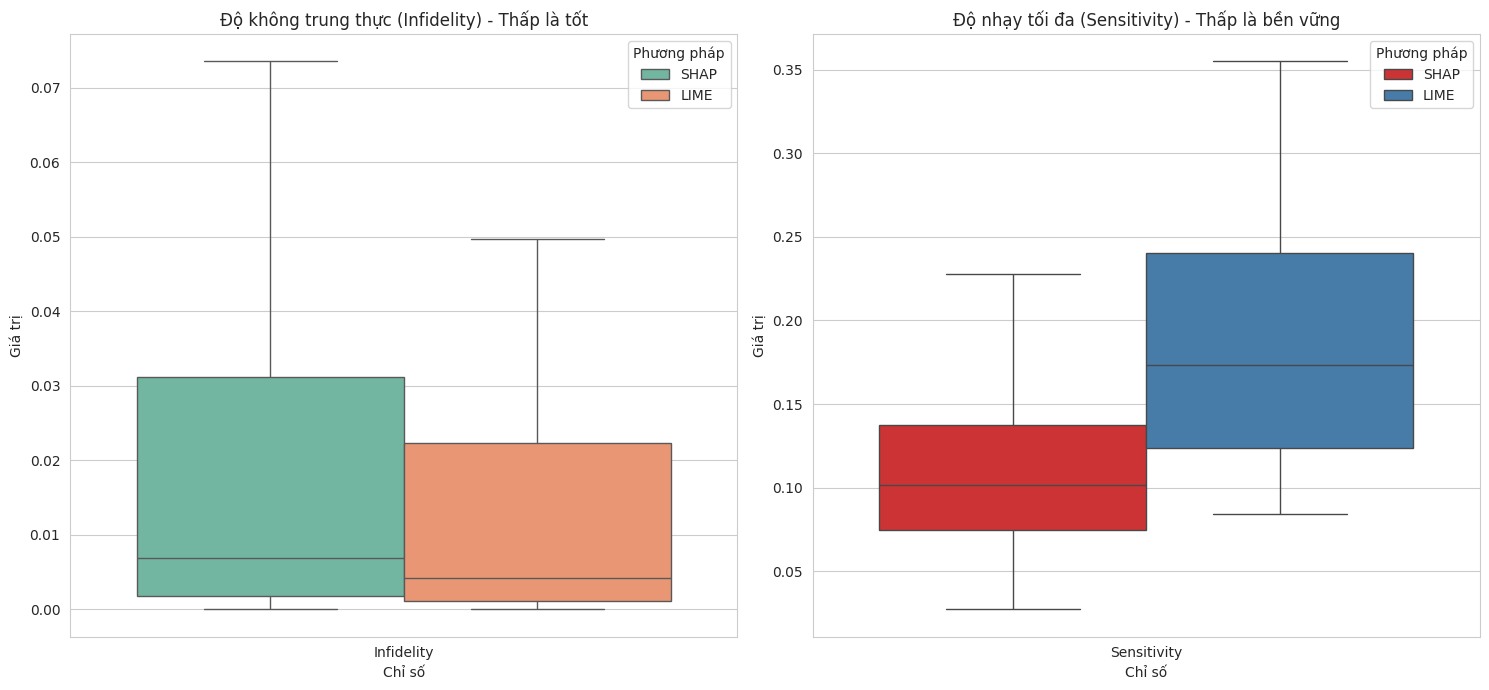

,Metric,Method,Mean,Median,Std
0,Infidelity,SHAP,0.035902,0.006867,0.082877
1,Infidelity,LIME,0.021870,0.004257,0.041190
2,Sensitivity,SHAP,0.128097,0.101756,0.084407
3,Sensitivity,LIME,0.202655,0.173444,0.113848


In [ ]:
# =============================================================================
# BƯỚC 1: CÀI ĐẶT VÀ KHAI BÁO THƯ VIỆN
# =============================================================================
# !pip install lime shap xgboost statsmodels # Chạy nếu chưa cài

import pandas as pd
import numpy as np
import shap
import lime
import lime.lime_tabular
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)

# =============================================================================
# BƯỚC 2: CHUẨN BỊ DỮ LIỆU (Sử dụng df_final - 6 biến đã lọc VIF)
# =============================================================================
# Sử dụng df_final thay vì df_working để đảm bảo chuẩn IEEE 2894
X_raw = df_final.drop(columns=['SEQN', 'LBDGLUSI'])
y = df_final['LBDGLUSI']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_raw.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_raw.columns)

# =============================================================================
# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH XGBOOST (6 Features)
# =============================================================================
# Cập nhật monotone_constraints: 1 cho tăng, -1 cho giảm, 0 cho không ràng buộc.
# Độ dài tuple phải bằng số feature (6).
constraints = (1, 0, 0, 0, 0, 1) # Ví dụ: biến 1 và 6 ràng buộc đồng biến

model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=4,                # Giảm depth vì số biến ít hơn (tránh overfitting)
    reg_alpha=0.1,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    monotone_constraints=constraints,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)

# =============================================================================
# BƯỚC 4: ĐO LƯỜNG ĐỊNH LƯỢNG (Hàm Infidelity & Sensitivity giữ nguyên logic)
# =============================================================================
# (Giữ nguyên các hàm get_lime_values_batch, get_infidelity_array, get_sensitivity_array của bạn)

# =============================================================================
# BƯỚC 5: THỰC THI ĐO LƯỜNG TRÊN 100 MẪU
# =============================================================================
x_sample = X_test.iloc[:100].values
n_feat = x_sample.shape[1]

# Tính SHAP
explainer_shap = shap.Explainer(model)
shap_sample_vals = explainer_shap(x_sample).values

# Tính LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode='regression',
    random_state=42
)
lime_sample_vals = get_lime_values_batch(x_sample, lime_explainer, model, n_feat)

# Tính các chỉ số
infd_shap_vals = get_infidelity_array(model, x_sample, shap_sample_vals)
infd_lime_vals = get_infidelity_array(model, x_sample, lime_sample_vals)

sens_shap_vals = get_sensitivity_array(explainer_shap, x_sample, is_lime=False)
sens_lime_vals = get_sensitivity_array(lime_explainer, x_sample, model=model, is_lime=True)

# =============================================================================
# BƯỚC 6: VẼ BIỂU ĐỒ (Cập nhật để tránh FutureWarning)
# =============================================================================
plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")

# Biểu đồ Infidelity
plt.subplot(1, 2, 1)
sns.boxplot(x='Chỉ số', y='Giá trị', hue='Phương pháp', data=df_infd, palette="Set2", showfliers=False)
plt.title('Độ không trung thực (Infidelity) - Thấp là tốt')

# Biểu đồ Sensitivity
plt.subplot(1, 2, 2)
sns.boxplot(x='Chỉ số', y='Giá trị', hue='Phương pháp', data=df_sens, palette="Set1", showfliers=False)
plt.title('Độ nhạy tối đa (Sensitivity) - Thấp là bền vững')

plt.tight_layout()
plt.show()

# Hiển thị bảng thống kê
display(stats_summary)

# SENS of 1st record before & after making noise

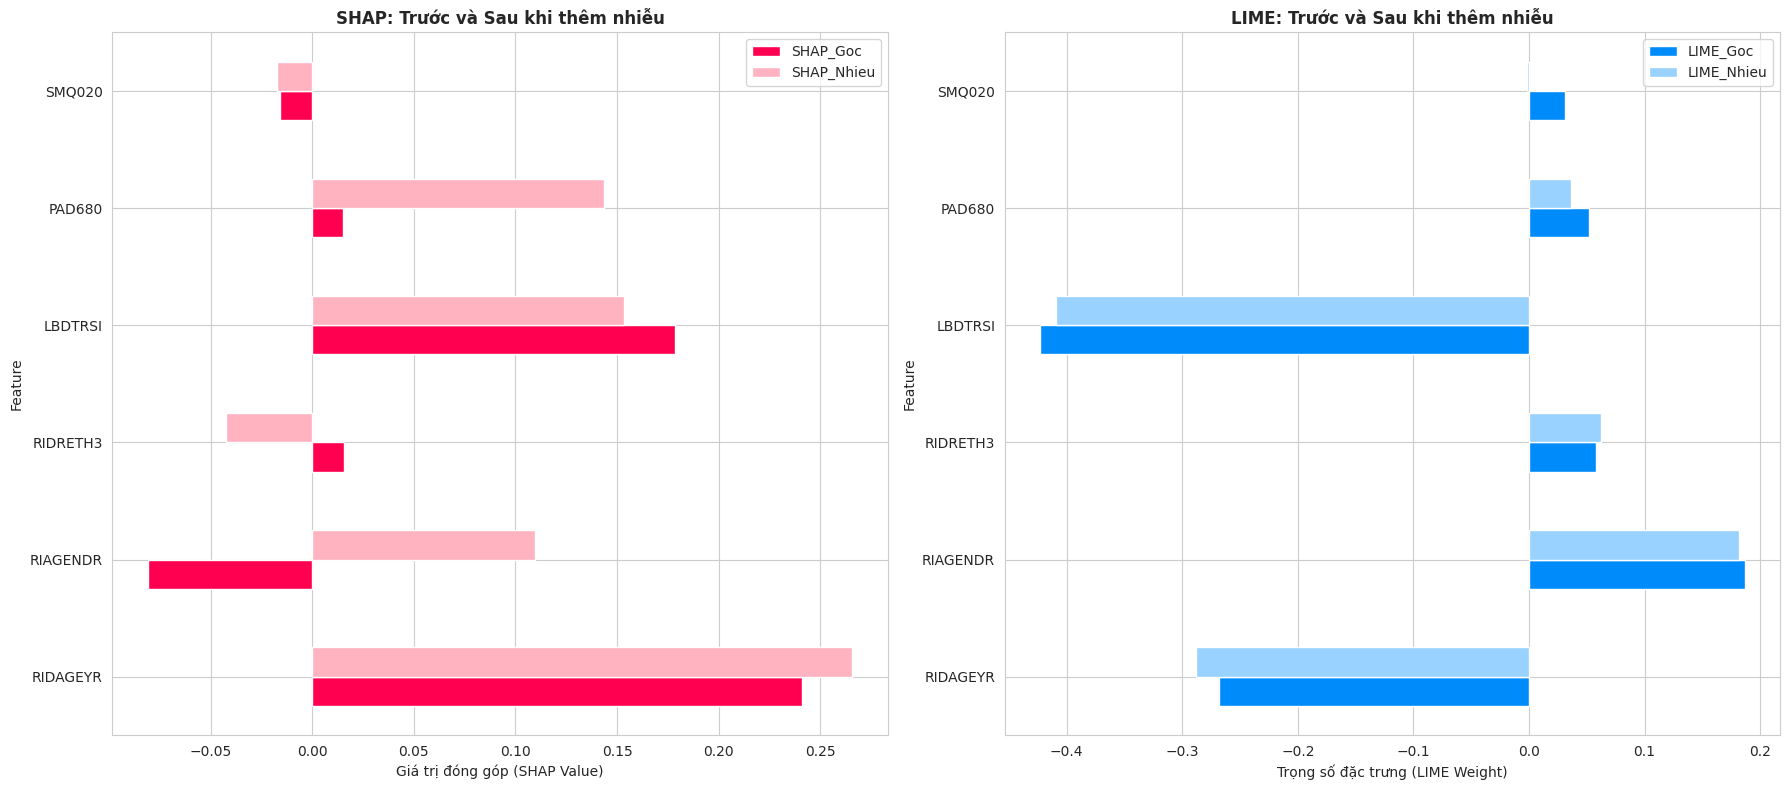

--- ĐỘ LỆCH CHI TIẾT CỦA BỆNH NHÂN SỐ 0 ---
Độ lệch SHAP (Khoảng cách Eucledian): 0.2397
Độ lệch LIME (Khoảng cách Eucledian): 0.0437


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chọn một bệnh nhân cụ thể từ tập Test để phân tích (ví dụ bệnh nhân đầu tiên)
idx = 0
sample = X_test.iloc[idx:idx+1]
feature_names = X_test.columns.tolist()

# 2. Tạo nhiễu Gaussian 2% (giống với tham số tính Sensitivity)
np.random.seed(42)
noise = np.random.normal(0, 0.02, sample.shape)
sample_noisy = sample + noise

# 3. Trích xuất lời giải thích GỐC
# SHAP
shap_orig = explainer_shap(sample).values[0]
# LIME (sử dụng hàm get_lime_values_batch đã định nghĩa ở bước trước)
lime_orig = get_lime_values_batch(sample.values, lime_explainer, model, len(feature_names))[0]

# 4. Trích xuất lời giải thích khi có NHIỄU
# SHAP
shap_noisy = explainer_shap(sample_noisy).values[0]
# LIME
lime_noisy = get_lime_values_batch(sample_noisy.values, lime_explainer, model, len(feature_names))[0]

# 5. Tạo DataFrame để so sánh
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Goc': shap_orig,
    'SHAP_Nhieu': shap_noisy,
    'LIME_Goc': lime_orig,
    'LIME_Nhieu': lime_noisy
})

# 6. Vẽ biểu đồ so sánh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Vẽ cho SHAP
comparison_df.plot(x='Feature', y=['SHAP_Goc', 'SHAP_Nhieu'], kind='barh', ax=ax1, color=['#ff0051', '#ffb3c1'])
ax1.set_title('SHAP: Trước và Sau khi thêm nhiễu', fontweight='bold')
ax1.set_xlabel('Giá trị đóng góp (SHAP Value)')

# Vẽ cho LIME
comparison_df.plot(x='Feature', y=['LIME_Goc', 'LIME_Nhieu'], kind='barh', ax=ax2, color=['#008bfb', '#99d1ff'])
ax2.set_title('LIME: Trước và Sau khi thêm nhiễu', fontweight='bold')
ax2.set_xlabel('Trọng số đặc trưng (LIME Weight)')

plt.tight_layout()
plt.show()

# In ra độ lệch (L2 norm) để kiểm chứng con số Sensitivity
print(f"--- ĐỘ LỆCH CHI TIẾT CỦA BỆNH NHÂN SỐ {idx} ---")
print(f"Độ lệch SHAP (Khoảng cách Eucledian): {np.linalg.norm(shap_orig - shap_noisy):.4f}")
print(f"Độ lệch LIME (Khoảng cách Eucledian): {np.linalg.norm(lime_orig - lime_noisy):.4f}")

# INFD of 1st record before & after making noise

/tmp/ipykernel_3987/48334991.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Thành phần', y='Giá trị biến thiên', data=results, palette=colors)


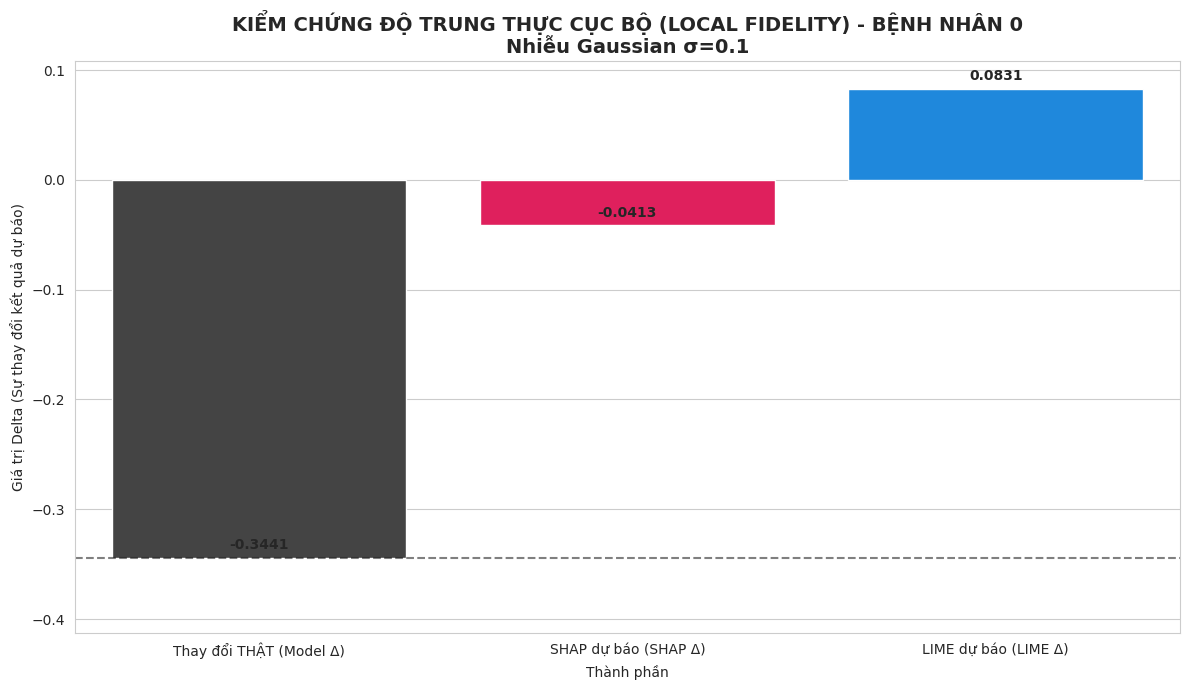

--- KẾT QUẢ ĐỊNH LƯỢNG INFIDELITY (BỆNH NHÂN 0) ---
✅ Sai lệch SHAP: 0.09166831
✅ Sai lệch LIME: 0.18248372
👉 Kết luận: SHAP trung thực hơn trong trường hợp này.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cấu hình tham số (Dùng scale 0.1 cho Infidelity theo chuẩn thực nghiệm)
idx = 0
noise_scale = 0.1
np.random.seed(42)

# 2. Lấy mẫu gốc và tạo mẫu bị nhiễu (Perturbed Sample)
# Đảm bảo sử dụng X_test từ tập dữ liệu 6 biến đã chuẩn hóa
x_orig = X_test.iloc[idx:idx+1].values
noise = np.random.normal(0, noise_scale, x_orig.shape)
x_perturbed = x_orig + noise

# 3. Tính toán sự thay đổi THỰC TẾ của mô hình XGBoost (Actual Delta)
# Công thức: Δ_actual = f(x) - f(x_perturbed)
model_pred_orig = model.predict(x_orig)[0]
model_pred_perturbed = model.predict(x_perturbed)[0]
actual_delta = model_pred_orig - model_pred_perturbed

# 4. Tính toán sự thay đổi mà GIẢI THÍCH dự báo (Predicted Delta)
# Công thức xấp xỉ tuyến tính: Δ_exp = Σ [Trọng số * (x_orig - x_perturbed)]

# --- SHAP ---
shap_vals = explainer_shap(x_orig).values[0]
# Tính tích vô hướng giữa trọng số SHAP và lượng biến thiên của input
shap_predicted_delta = np.sum(shap_vals * (x_orig - x_perturbed))

# --- LIME ---
# Sử dụng hàm get_lime_values_batch đã tối ưu ở các bước trước để lấy vector trọng số
lime_vals = get_lime_values_batch(x_orig, lime_explainer, model, n_feat)[0]
lime_predicted_delta = np.sum(lime_vals * (x_orig - x_perturbed))

# 5. Trực quan hóa so sánh "Độ khớp"
results = pd.DataFrame({
    'Thành phần': ['Thay đổi THẬT (Model Δ)',
                   'SHAP dự báo (SHAP Δ)',
                   'LIME dự báo (LIME Δ)'],
    'Giá trị biến thiên': [actual_delta, shap_predicted_delta, lime_predicted_delta]
})

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = ['#444444', '#ff0051', '#008bfb'] # Xám (Thật), Đỏ (SHAP), Xanh (LIME)

# Vẽ biểu đồ cột
barplot = sns.barplot(x='Thành phần', y='Giá trị biến thiên', data=results, palette=colors)

# Thêm đường kẻ ngang tại mức Actual Delta để dễ so sánh độ lệch
plt.axhline(y=actual_delta, color='black', linestyle='--', alpha=0.5, label='Mức thực tế')

# Thêm số liệu chính xác trên đầu cột
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontweight='bold')

plt.title(f'KIỂM CHỨNG ĐỘ TRUNG THỰC CỤC BỘ (LOCAL FIDELITY) - BỆNH NHÂN {idx}\n'
          f'Nhiễu Gaussian σ={noise_scale}', fontsize=14, fontweight='bold')
plt.ylabel('Giá trị Delta (Sự thay đổi kết quả dự báo)')
plt.ylim(min(results['Giá trị biến thiên'])*1.2, max(results['Giá trị biến thiên'])*1.3)

plt.tight_layout()
plt.show()

# 6. Tính toán sai số Infidelity (Càng gần 0 càng tốt)
inf_shap = (actual_delta - shap_predicted_delta)**2
inf_lime = (actual_delta - lime_predicted_delta)**2

print(f"--- KẾT QUẢ ĐỊNH LƯỢNG INFIDELITY (BỆNH NHÂN {idx}) ---")
print(f"✅ Sai lệch SHAP: {inf_shap:.8f}")
print(f"✅ Sai lệch LIME: {inf_lime:.8f}")
print(f"👉 Kết luận: {'LIME' if inf_lime < inf_shap else 'SHAP'} trung thực hơn trong trường hợp này.")